In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import OxfordIIITPet

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 128
BATCH_SIZE = 16
NUM_CLASSES = 3 # 1=pet, 2=background, 3=border of the pet
EPOCHS = 15
LR = 1e-3
print(f"Using device: {DEVICE}")

Using device: cuda


## Data set

In [ ]:
class PetSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, root = "./data", split="trainval", img_size=IMG_SIZE):
        self.base = OxfordIIITPet(
            root = root,
            split = split,
            target_types = "segmentation",
            download=True
        )
        self.img_size = img_size
        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])
        self.mask_resize = transforms.Resize(
            (img_size, img_size),
            interpolation=transforms.InterpolationMode.NEAREST
        )
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        image, mask = self.base[idx]
        image = self.img_transform(image)
        mask = self.mask_resize(mask)
        mask = torch.as_tensor(np.array(mask),dtype=torch.long)
        mask = mask-1 # original value are {1,2,3}, after -1 the values {0,1,2} for CrossEntropyLoss.
        return image, mask

## U-net

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch,):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,out_ch,kernel_size=3,padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch,out_ch,kernel_size=3,padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self,x):
        return self.block(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=NUM_CLASSES,features = (64,128,256,512)):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Encoder
        self.encoders = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch,f))
            ch = f
        # Bottleneck
        self.bottleneck = DoubleConv(features[-1],features[-1]*2)
        # Decoder
        self.upconvs = nn.ModuleList()
        self.decoders = nn.ModuleList()
        rev_features = features[::-1]
        in_ch = features[-1]*2
        for f in rev_features:
            self.upconvs.append(nn.ConvTranspose2d(in_ch,f,kernel_size=3, stride=2))
            self.decoders.append(DoubleConv(f*2,f))
            in_ch = f
        # final conv
        self.final_conv = nn.Conv2d(features[0],num_classes,kernel_size=1)
    def forward(self,x):
        skip_connections = []
        # Encoder pass
        for enc in self.encoders:
            x = enc(x)
            skip_connections.append(x)
            x = self.pool(x)
        # Bottleneck pass
        x = self.bottleneck(x)
        # reverse skip_connections
        skip_connections = skip_connections[::-1]
        # Decoder pass
        for i in range(len(self.decoders)):
            # upsample
            x = self.upconvs[i](x)
            skip = skip_connections[i]
            # safety: if odd input sizes causes a 1px mismatch, crop/pad
            if x.shape !=skip.shape:
                x = F.interpolate(x, skip.shape[2:])
            # concat along channel dimension
            x = torch.cat([skip,x],dim=1)
            # apply double conv
            x = self.decoders[i](x)

        return self.final_conv(x)  # [B, num_classes, H,W]


## Metric - Intersection over union(IOU)

In [ ]:
@torch.no_grad()
def compute_iou(preds, masks, num_classes=NUM_CLASSES):
    ious = []
    for cls in range(num_classes):
        pred_cls = (preds==cls)
        mask_cls = (masks==cls)
        intersection = (pred_cls & mask_cls).sum().item()
        union = (pred_cls | mask_cls).sum().item()
        if union==0:
            continue # class not present in the batch. skip it
        ious.append(intersection/union)
    return sum(ious)/len(ious) if ious else 0.0

# Training Loop

In [ ]:
def train():
    train_ds = PetSegmentationDataset(split="trainval")
    test_ds = PetSegmentationDataset(split="test")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,shuffle=True, num_workers=2)
    test_loader = DataLoader(test_ds,batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = UNet(in_channels=3,num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=LR)
    scheduler= optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    for epoch in range(1,EPOCHS+1):
        # train
        model.train()
        running_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()*images.size(0)
        training_loss = running_loss/len(train_ds)
        scheduler.step()
        # validate
        model.eval()
        val_loss, val_iou, n_batches = 0.0, 0.0, 0
        with torch.no_grad():
            for images, masks in test_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                logits = model(images)
                loss = criterion(logits,masks)
                preds = torch.argmax(logits, dim=1)

                val_loss += loss.item()*images.size(0)
                val_iou += compute_iou(preds, masks)
                n_batches +=1
        val_loss /= len(test_ds)
        val_iou /= n_batches
        print(f"Epoch [{epoch:02d}/{EPOCHS}] train_loss = {training_loss:.4f} val_loss = {val_loss:.4f} val_mIOU = {val_iou:.4f}")

    # torch.save(model.state_dict(), "unet_pets.pth")
    # print("Model saved")

    return model, test_ds

In [ ]:
model,test_ds  = train()

100%|██████████| 792M/792M [00:40<00:00, 19.7MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.42MB/s]


Epoch [01/15] train_loss = 0.6541 val_loss = 0.5879 val_mIOU = 0.5123
Epoch [02/15] train_loss = 0.5411 val_loss = 0.5117 val_mIOU = 0.5629
Epoch [03/15] train_loss = 0.4704 val_loss = 0.4534 val_mIOU = 0.5881
Epoch [04/15] train_loss = 0.4190 val_loss = 0.5576 val_mIOU = 0.5586
Epoch [05/15] train_loss = 0.3786 val_loss = 0.3907 val_mIOU = 0.6362
Epoch [06/15] train_loss = 0.3522 val_loss = 0.3518 val_mIOU = 0.6687
Epoch [07/15] train_loss = 0.3258 val_loss = 0.3467 val_mIOU = 0.6709
Epoch [08/15] train_loss = 0.3053 val_loss = 0.3427 val_mIOU = 0.6796
Epoch [09/15] train_loss = 0.2838 val_loss = 0.3352 val_mIOU = 0.6900
Epoch [10/15] train_loss = 0.2652 val_loss = 0.2998 val_mIOU = 0.7057
Epoch [11/15] train_loss = 0.2481 val_loss = 0.2839 val_mIOU = 0.7148
Epoch [12/15] train_loss = 0.2325 val_loss = 0.2795 val_mIOU = 0.7235
Epoch [13/15] train_loss = 0.2186 val_loss = 0.2750 val_mIOU = 0.7279
Epoch [14/15] train_loss = 0.2134 val_loss = 0.2732 val_mIOU = 0.7300
Epoch [15/15] train_

## Visualization

In [ ]:
# back to original values
def denormalize(img_tensor):
    # normalized = (original - mean) / std -> original = normalized * std + mean
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor.cpu() * std + mean).clamp(0,1)

In [ ]:
@torch.no_grad()
def visualize(model, dataset, n=4):
    model.eval()
    fig, axes = plt.subplots(n,3, figsize=(9, 3*n))
    for i in range(n):
        image, mask = dataset[i]
        logits = model(image.unsqueeze(0).to(DEVICE))  # model expects a batch size images
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu() # removes fake batch D
        axes[i,0].imshow(denormalize(image).permute(1,2,0))
        axes[i,0].set_title("Input Image")
        axes[i,1].imshow(mask,cmap="viridis",vmin=0, vmax=2)
        axes[i,1].set_title("Ground Truth Mask")
        axes[i,2].imshow(pred, cmap="viridis", vmin=0, vmax=2)
        axes[i,2].set_title("Predicted Mask")
        for ax in axes[i]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()

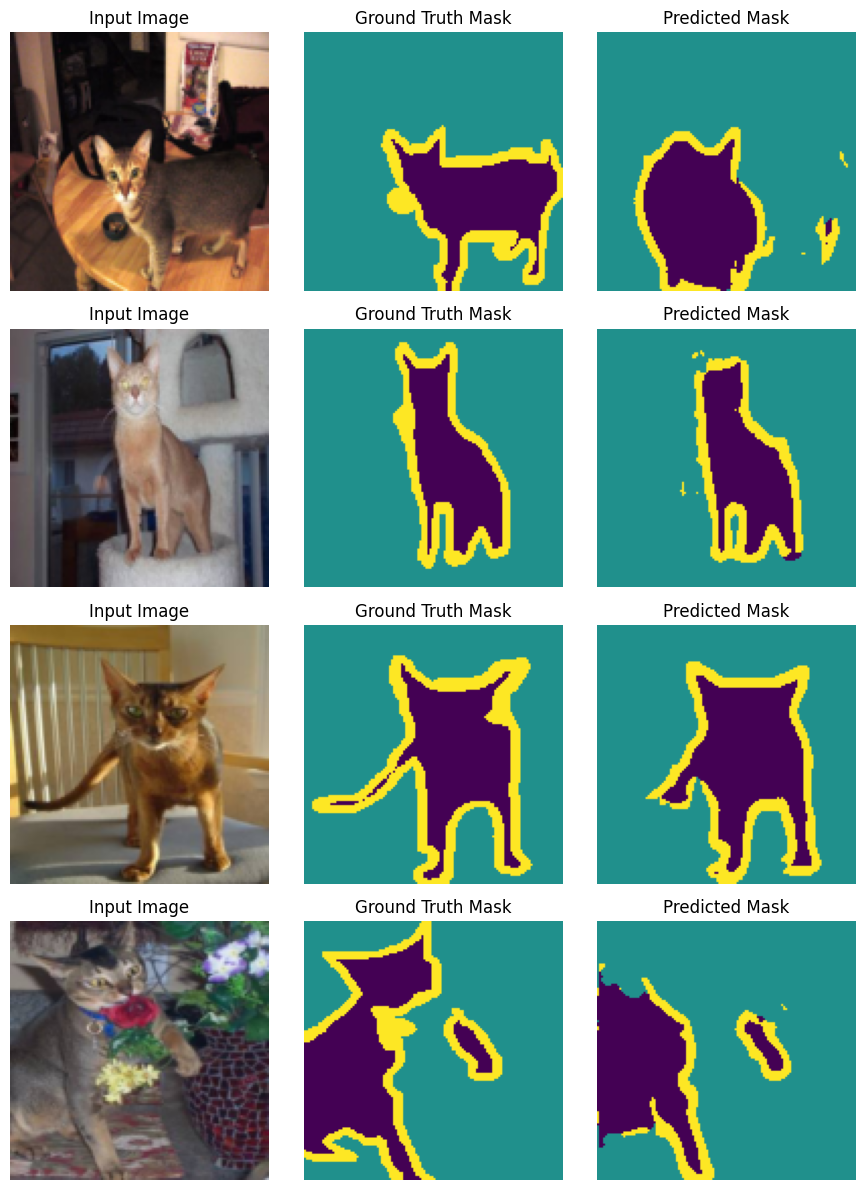

In [ ]:
visualize(model, test_ds)